<a href="https://colab.research.google.com/github/aycaaozturk/AML-project/blob/main/AML_missing_value_analysis_clinical_patient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================
# PART 1: Missing Data Analysis
# AML Clinical Dataset
# ================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional, for nicer missingness visualizations
!pip install missingno

import missingno as msno

Mounted at /content/drive


In [ ]:
# 1) Load dataset

file_path = "/content/drive/MyDrive/Uniklinikum Würzburg/AML/AML Dataset/aml_target_2018_pub/data_clinical_patient.txt"


df = pd.read_csv(
    file_path,
    sep="\t",
    header=4,
    na_values=["", " ", "NA", "N/A", "NaN"]
)



print("Dataset shape:", df.shape)
df.head()

Dataset shape: (899, 35)


,PATIENT_ID,PROTOCOL,SEX,RACE,ETHNICITY,AGE_IN_DAYS,AGE,WBC,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,PERIPHERAL_BLASTS_PERCENTAGE,...,CR_STATUS_AT_END_OF_COURSE_2,RISK_GROUP,DAYS_TO_EVENT,FIRST_EVENT,OS_STATUS,OS_DAYS,OS_MONTHS,SCT_IN_FIRST_CR,CHLOROMA_RELAPSE_SITE,CYTOGENETIC_RELAPSE_SITE
0,TARGET-20-PABLDZ,CCG-2961,Female,White,Not Hispanic or Latino,2455.0,7.0,6.0,93.0,0.0,...,CR,High,714.0,Relapse,0:LIVING,721.0,24.0,No,No,No
1,TARGET-20-PADYIR,CCG-2961,Male,White,Not Hispanic or Latino,1159.0,4.0,13.1,29.0,11.0,...,CR,Unknown,373.0,Relapse,1:DECEASED,585.0,20.0,Yes,No,No
2,TARGET-20-PADZCG,CCG-2961,Female,Unknown,Not Hispanic or Latino,5325.0,15.0,29.3,58.0,5.0,...,CR,Standard,314.0,Relapse,1:DECEASED,536.0,18.0,No,No,No
3,TARGET-20-PADZKD,CCG-2961,Female,Black or African American,Not Hispanic or Latino,4887.0,14.0,40.2,56.0,61.0,...,CR,Low,385.0,Relapse,0:LIVING,1346.0,45.0,No,No,No
4,TARGET-20-PADZYC,CCG-2961,Male,Unknown,Hispanic or Latino,1630.0,5.0,200.0,98.0,97.0,...,CR,Standard,223.0,Death,1:DECEASED,223.0,8.0,No,Not done,Not done


In [ ]:
# 2) Treat clinical missing-like values as NaN

missing_like = [
      "Unknown",
    "UNKNOWN",
    "Not Done",
    "Not done",
    "NOT DONE",
    "Unevaluable",
    "Not available",
    "Not reported",
    "Missing",
    "NA",
    "N/A"
]

df = df.replace(missing_like, np.nan)

print("Dataset shape after replacing missing-like values:", df.shape)
df.head()

Dataset shape after replacing missing-like values: (899, 35)


,PATIENT_ID,PROTOCOL,SEX,RACE,ETHNICITY,AGE_IN_DAYS,AGE,WBC,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,PERIPHERAL_BLASTS_PERCENTAGE,...,CR_STATUS_AT_END_OF_COURSE_2,RISK_GROUP,DAYS_TO_EVENT,FIRST_EVENT,OS_STATUS,OS_DAYS,OS_MONTHS,SCT_IN_FIRST_CR,CHLOROMA_RELAPSE_SITE,CYTOGENETIC_RELAPSE_SITE
0,TARGET-20-PABLDZ,CCG-2961,Female,White,Not Hispanic or Latino,2455.0,7.0,6.0,93.0,0.0,...,CR,High,714.0,Relapse,0:LIVING,721.0,24.0,No,No,No
1,TARGET-20-PADYIR,CCG-2961,Male,White,Not Hispanic or Latino,1159.0,4.0,13.1,29.0,11.0,...,CR,NaN,373.0,Relapse,1:DECEASED,585.0,20.0,Yes,No,No
2,TARGET-20-PADZCG,CCG-2961,Female,NaN,Not Hispanic or Latino,5325.0,15.0,29.3,58.0,5.0,...,CR,Standard,314.0,Relapse,1:DECEASED,536.0,18.0,No,No,No
3,TARGET-20-PADZKD,CCG-2961,Female,Black or African American,Not Hispanic or Latino,4887.0,14.0,40.2,56.0,61.0,...,CR,Low,385.0,Relapse,0:LIVING,1346.0,45.0,No,No,No
4,TARGET-20-PADZYC,CCG-2961,Male,NaN,Hispanic or Latino,1630.0,5.0,200.0,98.0,97.0,...,CR,Standard,223.0,Death,1:DECEASED,223.0,8.0,No,NaN,NaN


In [ ]:
# 3) Basic missing-value overview

missing_counts = df.isna().sum()
missing_percentages = df.isna().mean() * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_percentages
})

missing_summary = missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

missing_summary.head(35)

,missing_count,missing_percentage
CKIT_EXON_17_MUTATION,675,75.083426
CKIT_EXON_8_MUTATION,674,74.972191
CYTOGENETIC_CODE_OTHER,628,69.855395
OTHER_MLL,593,65.962180
CHLOROMA_RELAPSE_SITE,496,55.172414
CYTOGENETIC_RELAPSE_SITE,496,55.172414
MRD_AT_END_OF_COURSE_2,286,31.813126
MRD_PERCENTAGE_AT_END_OF_COURSE_2,286,31.813126
MRD_PERCENTAGE_AT_END_OF_COURSE_1,194,21.579533
MRD_AT_END_OF_COURSE_1,193,21.468298


In [ ]:
# 4) Show only columns that have missing values

columns_with_missing = missing_summary[missing_summary["missing_count"] > 0]

print("Number of columns with missing values:", columns_with_missing.shape[0])
columns_with_missing

Number of columns with missing values: 34


,missing_count,missing_percentage
CKIT_EXON_17_MUTATION,675,75.083426
CKIT_EXON_8_MUTATION,674,74.972191
CYTOGENETIC_CODE_OTHER,628,69.855395
OTHER_MLL,593,65.962180
CHLOROMA_RELAPSE_SITE,496,55.172414
CYTOGENETIC_RELAPSE_SITE,496,55.172414
MRD_AT_END_OF_COURSE_2,286,31.813126
MRD_PERCENTAGE_AT_END_OF_COURSE_2,286,31.813126
MRD_PERCENTAGE_AT_END_OF_COURSE_1,194,21.579533
MRD_AT_END_OF_COURSE_1,193,21.468298


In [ ]:
# 5) Save missingness summary as CSV

missing_summary_path = "/content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/missingness_summary.csv"

missing_summary.to_csv(missing_summary_path)

print("Missingness summary saved to:", missing_summary_path)

Missingness summary saved to: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/missingness_summary.csv


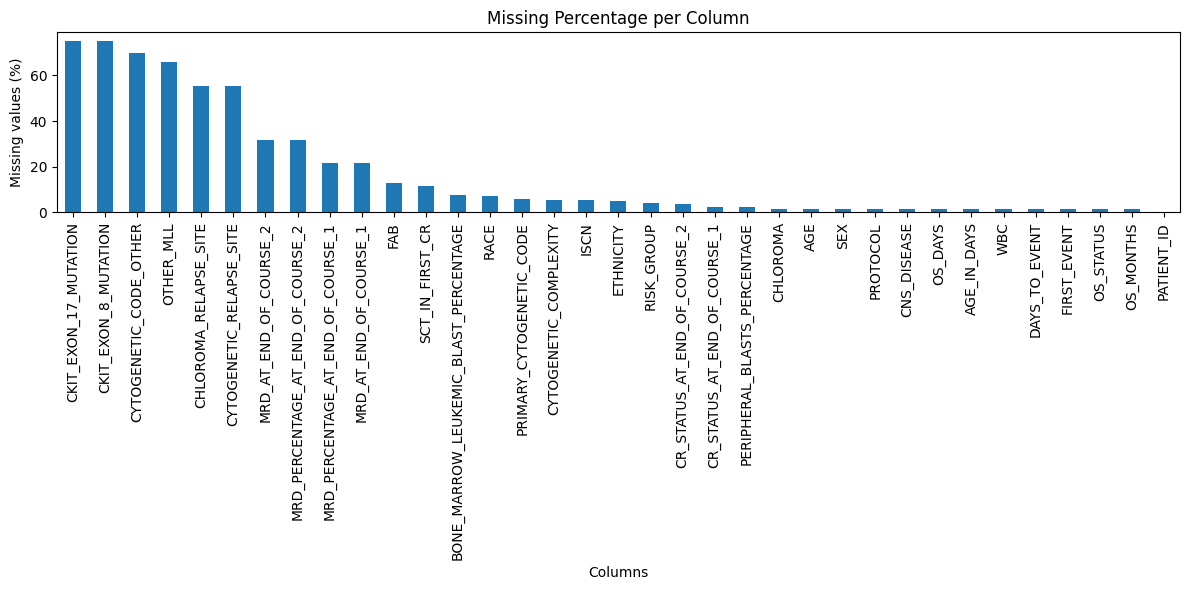

In [ ]:
# 6) Plot missing percentage per column

plt.figure(figsize=(12, 6))

missing_summary["missing_percentage"].plot(kind="bar")

plt.ylabel("Missing values (%)")
plt.xlabel("Columns")
plt.title("Missing Percentage per Column")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

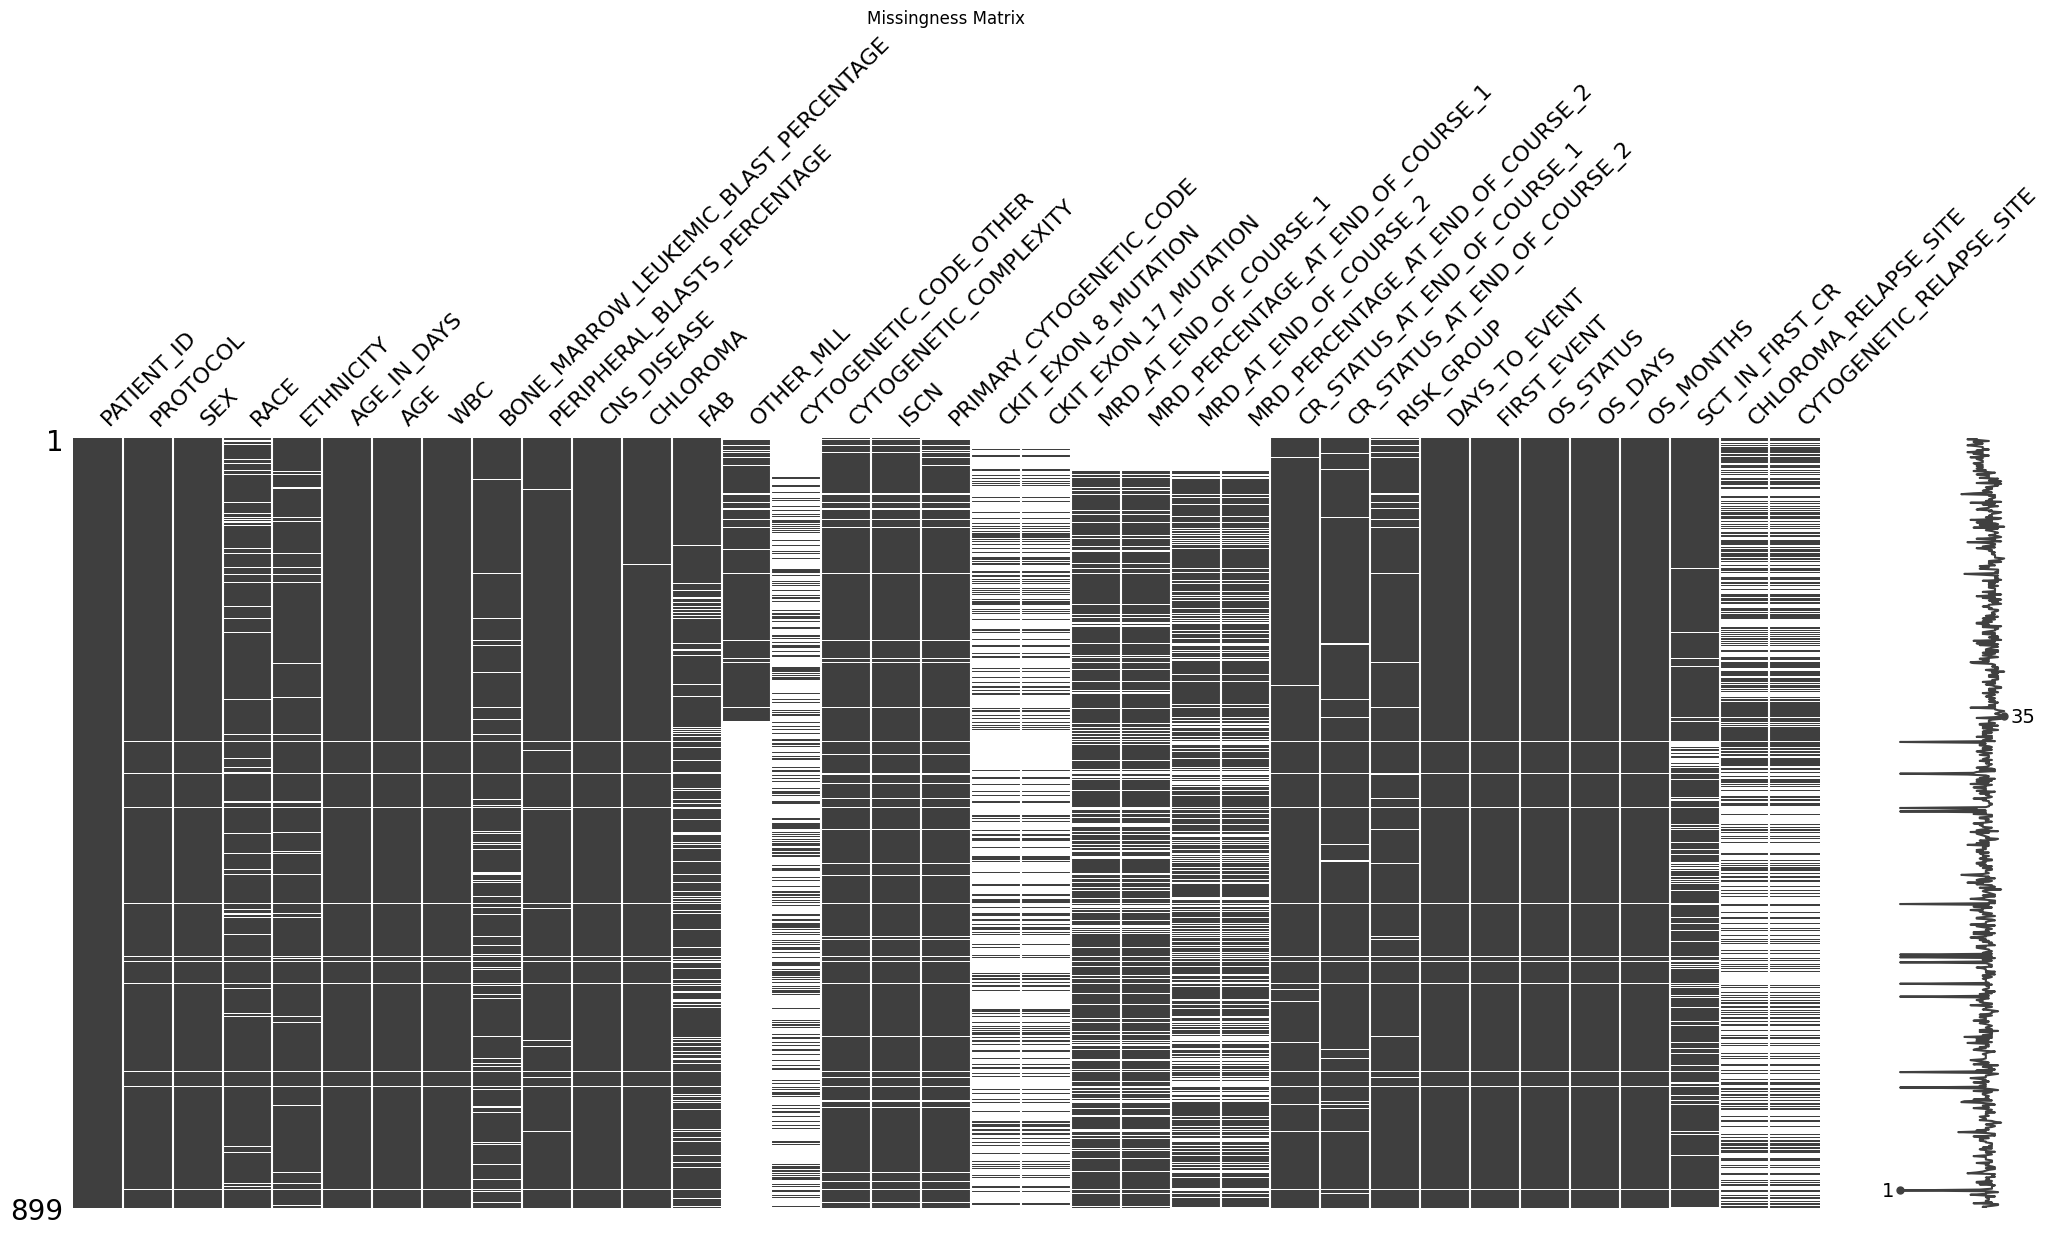

In [ ]:
# 7) Missingness matrix visualization

msno.matrix(df)
plt.title("Missingness Matrix")
plt.show()

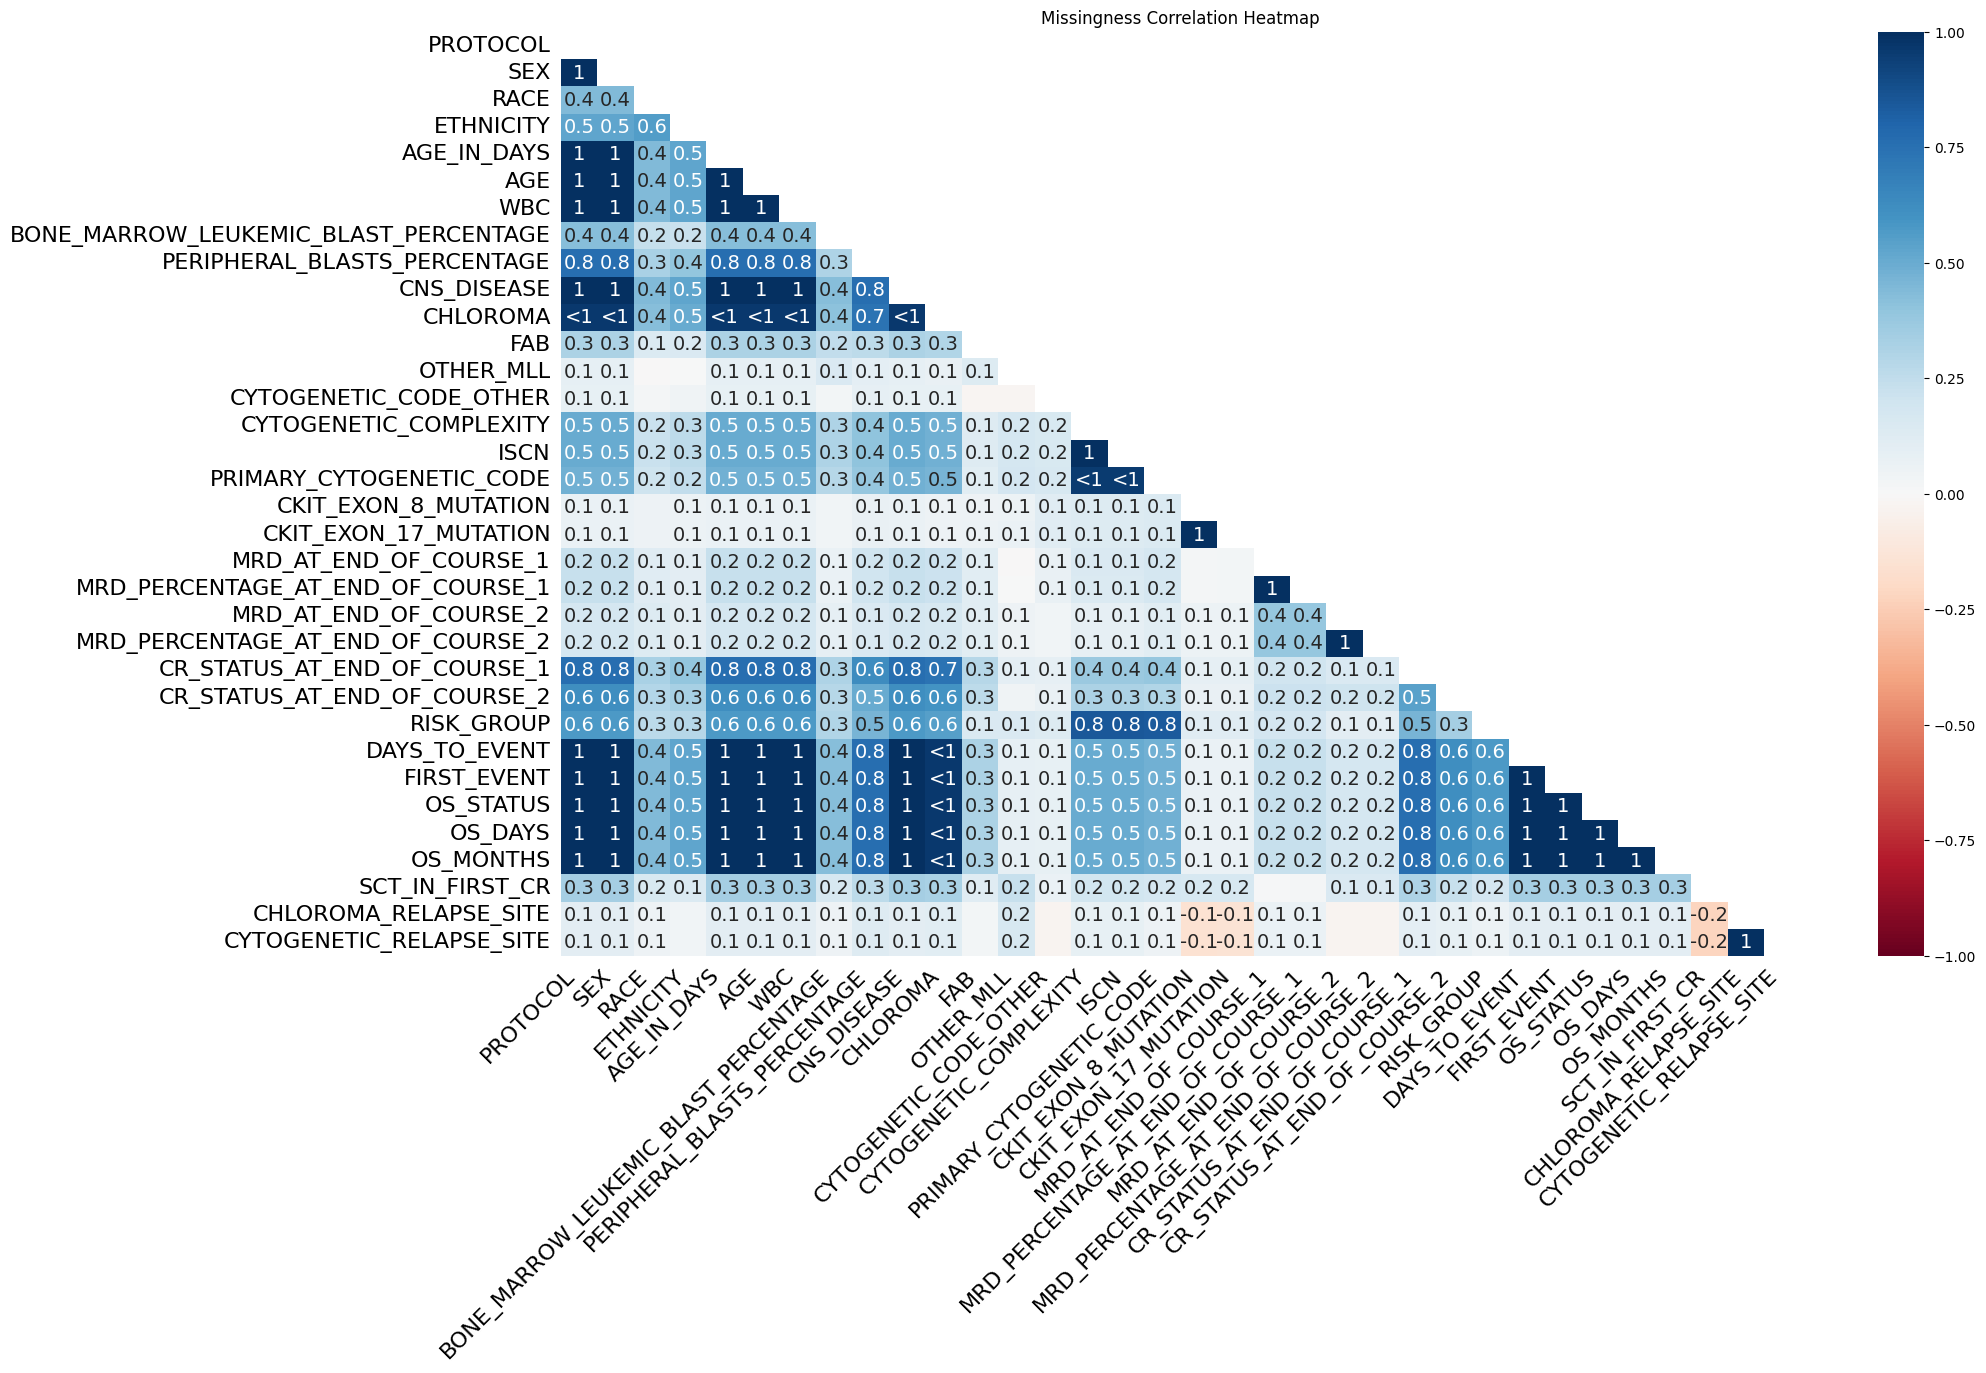

In [ ]:
# 8) Missingness heatmap
# Shows whether missing values in different columns occur together

msno.heatmap(df)
plt.title("Missingness Correlation Heatmap")
plt.show()

In [ ]:
# 9) Check excessive missingness

# You can change this threshold.
# Common choices: 50%, 70%, or 80%
missing_threshold = 25

excessive_missing_cols = missing_summary[
    missing_summary["missing_percentage"] >= missing_threshold
]

print(f"Columns with >= {missing_threshold}% missing values:")
excessive_missing_cols

Columns with >= 25% missing values:


,missing_count,missing_percentage
CKIT_EXON_17_MUTATION,675,75.083426
CKIT_EXON_8_MUTATION,674,74.972191
CYTOGENETIC_CODE_OTHER,628,69.855395
OTHER_MLL,593,65.962180
CHLOROMA_RELAPSE_SITE,496,55.172414
CYTOGENETIC_RELAPSE_SITE,496,55.172414
MRD_AT_END_OF_COURSE_2,286,31.813126
MRD_PERCENTAGE_AT_END_OF_COURSE_2,286,31.813126


In [ ]:
# 10) Create a cleaned version WITHOUT excessive-missingness columns
# but keep clinically important columns manually

important_cols_to_keep = [
    # "CKIT_EXON_17_MUTATION",
    # "CKIT_EXON_8_MUTATION"
]

cols_to_drop = excessive_missing_cols.index.tolist()

# Remove important columns from the drop list
cols_to_drop = [
    col for col in cols_to_drop
    if col not in important_cols_to_keep
]

df_reduced = df.drop(columns=cols_to_drop)

print("Original shape:", df.shape)
print("Reduced shape:", df_reduced.shape)
print("Protected columns kept:", important_cols_to_keep)
print("Dropped columns:", cols_to_drop)

Original shape: (899, 35)
Reduced shape: (899, 27)
Protected columns kept: []
Dropped columns: ['CKIT_EXON_17_MUTATION', 'CKIT_EXON_8_MUTATION', 'CYTOGENETIC_CODE_OTHER', 'OTHER_MLL', 'CHLOROMA_RELAPSE_SITE', 'CYTOGENETIC_RELAPSE_SITE', 'MRD_AT_END_OF_COURSE_2', 'MRD_PERCENTAGE_AT_END_OF_COURSE_2']


In [ ]:
# 11) Save reduced dataset

reduced_output_path = "/content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/REDUCED_clinical_patient_missingness_checked.csv"

df_reduced.to_csv(reduced_output_path, index=False)

print("Reduced dataset saved to:", reduced_output_path)

Reduced dataset saved to: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/REDUCED_clinical_patient_missingness_checked.csv
